# Regression Evaluation

Data and model artifacts are intentionally external to this repository. Configure their locations in `.env` before running the notebook.


In [ ]:
# Reproducible project paths (launch Jupyter from the repository root)
import os
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "README.md").is_file():
    PROJECT_ROOT = next(
        (parent for parent in PROJECT_ROOT.parents if (parent / "README.md").is_file()),
        PROJECT_ROOT,
    )

load_dotenv(PROJECT_ROOT / ".env")
DATA_ROOT = Path(os.getenv("SOIL_DATA_DIR", PROJECT_ROOT / "data")).expanduser()
MODEL_ROOT = Path(os.getenv("SOIL_MODEL_DIR", PROJECT_ROOT / "models")).expanduser()
OUTPUT_ROOT = Path(os.getenv("SOIL_OUTPUT_DIR", PROJECT_ROOT / "outputs")).expanduser()

if not DATA_ROOT.is_absolute():
    DATA_ROOT = PROJECT_ROOT / DATA_ROOT
if not MODEL_ROOT.is_absolute():
    MODEL_ROOT = PROJECT_ROOT / MODEL_ROOT
if not OUTPUT_ROOT.is_absolute():
    OUTPUT_ROOT = PROJECT_ROOT / OUTPUT_ROOT

MODEL_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / ".cache").mkdir(parents=True, exist_ok=True)
(OUTPUT_ROOT / ".cache").mkdir(parents=True, exist_ok=True)


In [1]:
import os, zipfile, glob
import torch, cv2, rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import models
from torch import nn
from collections import defaultdict

In [7]:
labels_path = os.getenv("REGRESSION_LABELS_PATH", str(DATA_ROOT / "weather" / "Dair_Alla.csv"))
df = pd.read_csv(labels_path)
y_mean = df['soil_moisture_0_to_7cm'].mean()
y_std  = df['soil_moisture_0_to_7cm'].std()

print(f"y_mean = {y_mean:.6f}, y_std = {y_std:.6f}")

y_mean = 0.074219, y_std = 0.072210


<LOCAL_TEMP>\ipykernel_6688\3255459980.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))


2023-08-18: Moisture = 0.07352 (Low)
2025-01-09: Moisture = 0.15498 (Moderate)
2025-01-14: Moisture = 0.09843 (Low)
2025-01-19: Moisture = 0.14749 (Moderate)
2025-03-25: Moisture = 0.07895 (Low)
2025-06-18: Moisture = 0.09612 (Low)
2025-06-20: Moisture = 0.09126 (Low)
2025-06-28: Moisture = 0.07517 (Low)


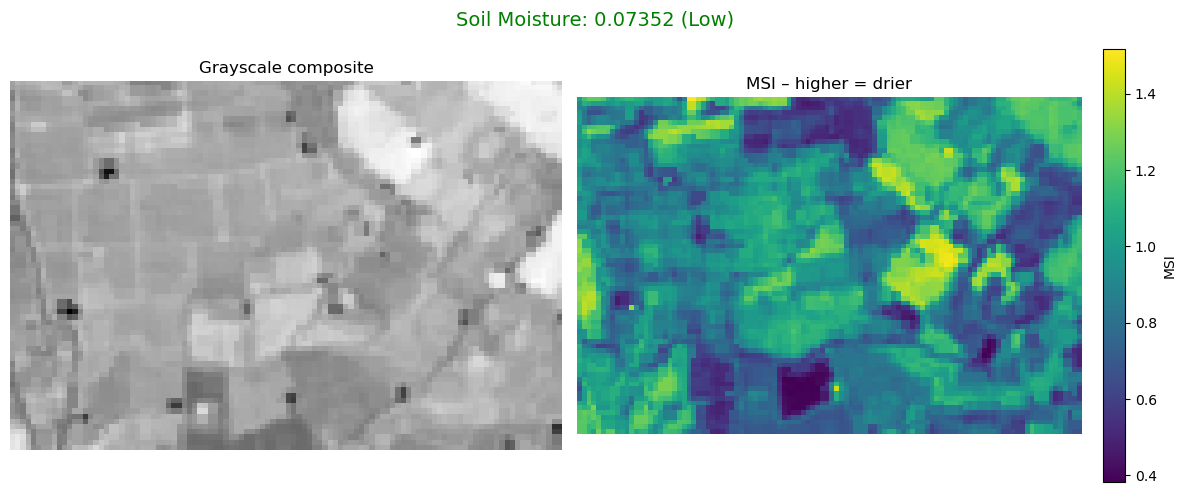

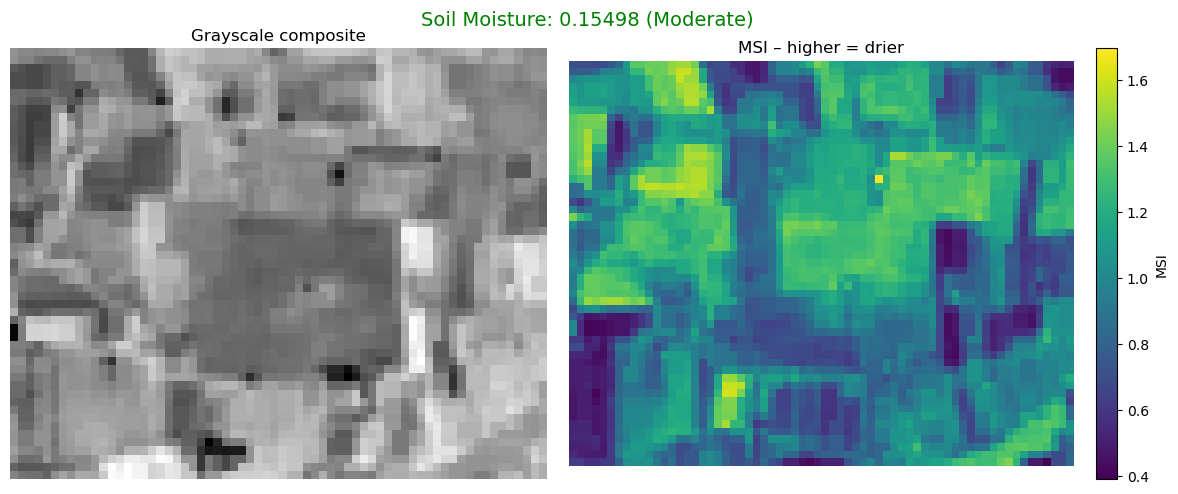

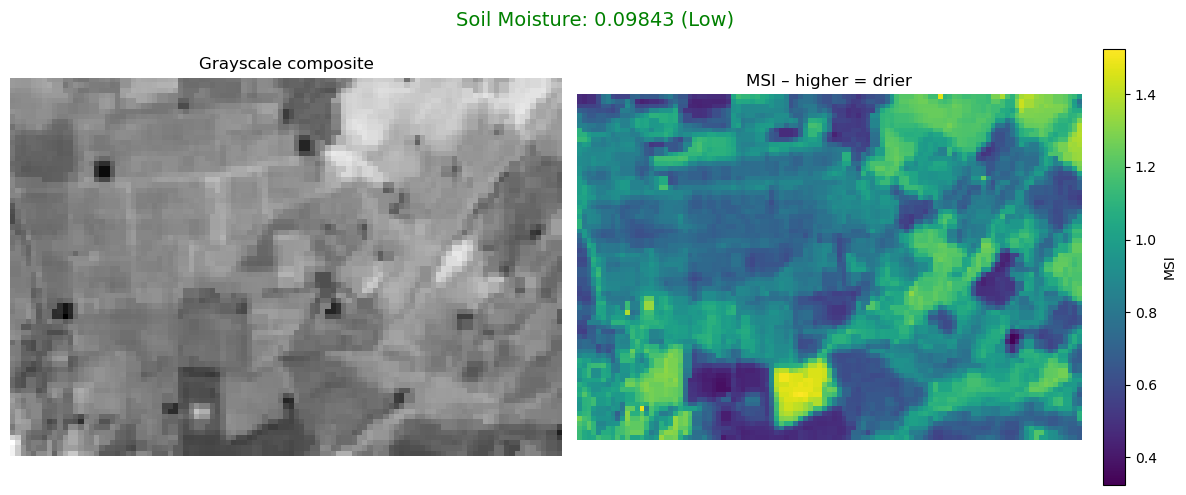

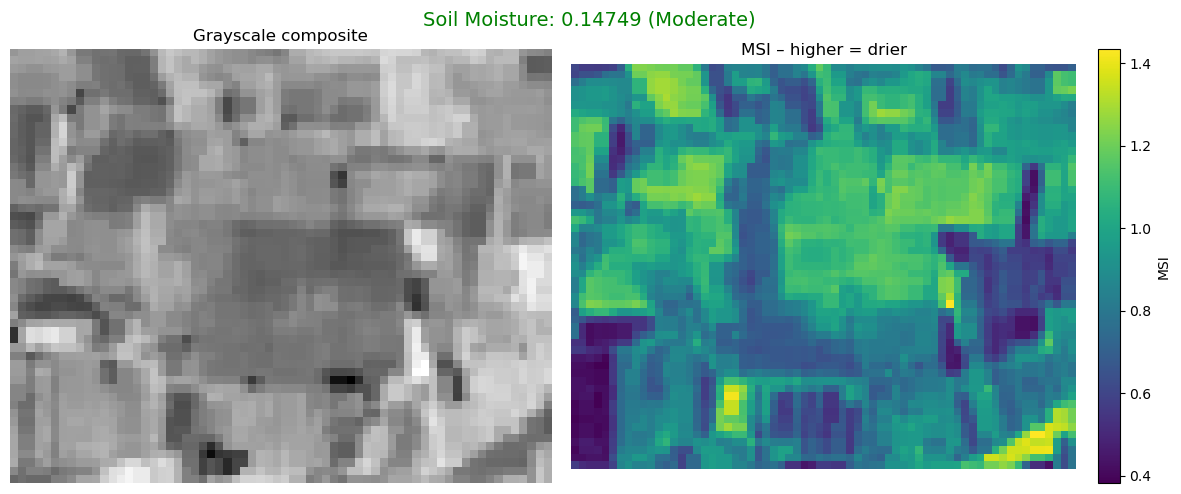

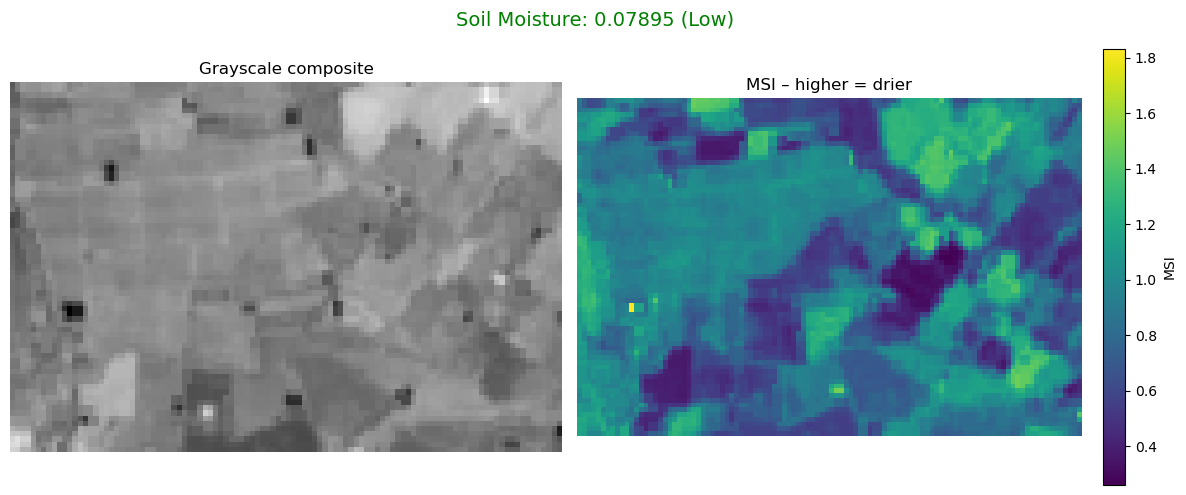

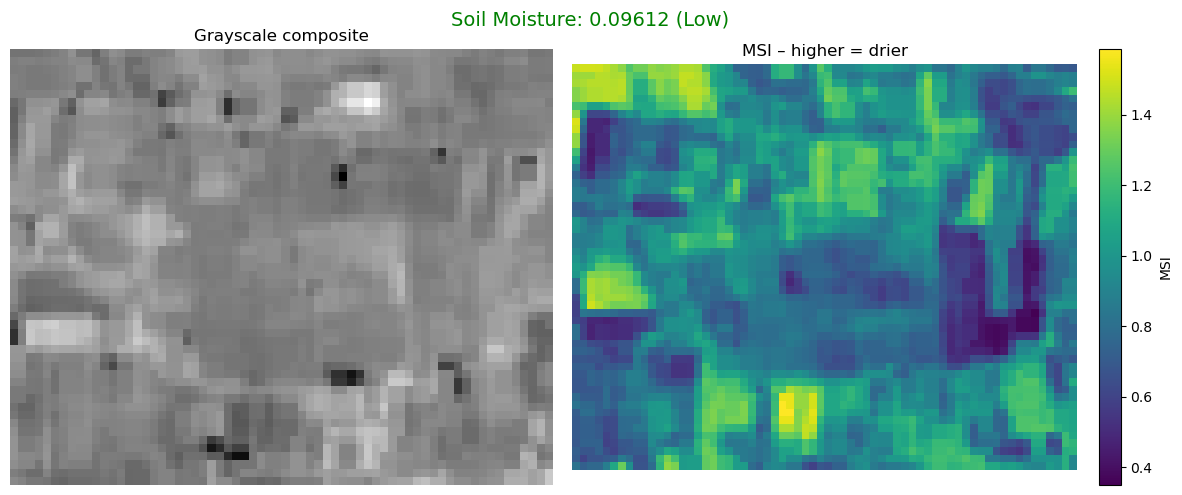

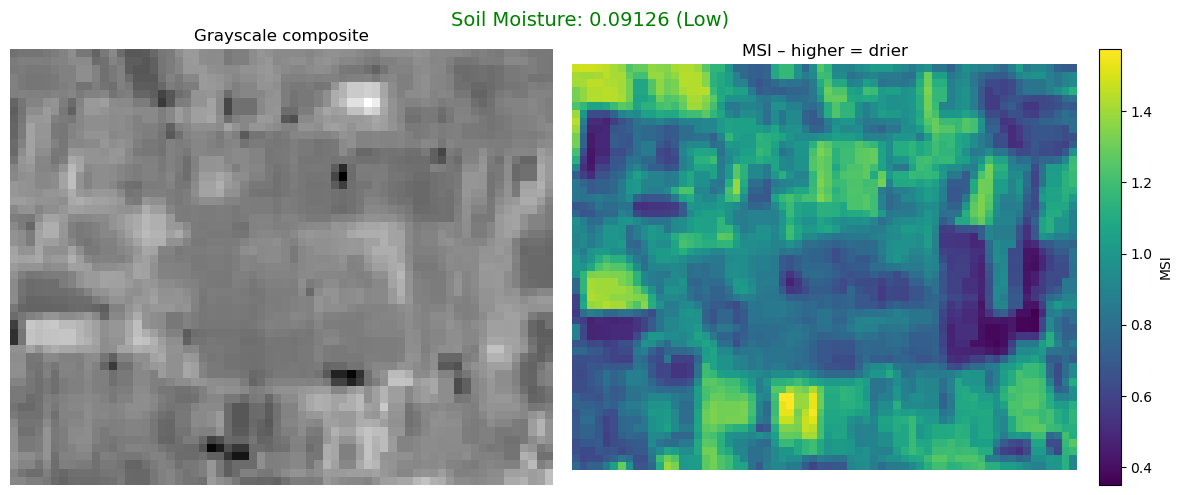

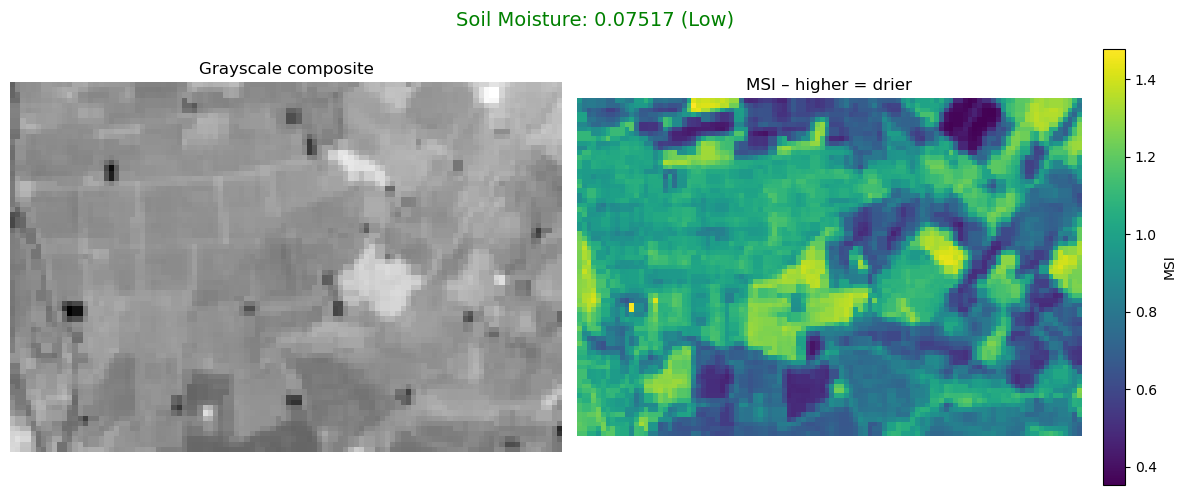

In [9]:
# ──────────────────────────────────────────────────────
# 1. Paths
# ──────────────────────────────────────────────────────
base_dir = str(DATA_ROOT / "testing" / "regression")
zip_dir = os.path.join(base_dir, "archives")
extract_dir = os.path.join(base_dir, "extracted")
merged_dir = str(OUTPUT_ROOT / "regression_evaluation")
model_path = os.getenv("REGRESSION_MODEL_PATH", str(MODEL_ROOT / "regression.pth"))
os.makedirs(extract_dir, exist_ok=True)
os.makedirs(merged_dir, exist_ok=True)

# ──────────────────────────────────────────────────────
# 2. Extract all zip files
# ──────────────────────────────────────────────────────
for zip_file in glob.glob(os.path.join(zip_dir, "*.zip")):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

# ──────────────────────────────────────────────────────
# 3. Group B8A and B11 files
# ──────────────────────────────────────────────────────
all_files = glob.glob(os.path.join(extract_dir, '*.tif*'))
grouped = defaultdict(dict)

for f in all_files:
    fname = os.path.basename(f)
    date = fname[:10]
    if 'B8A' in fname.upper():
        grouped[date]['B8A'] = f
    elif 'B11' in fname.upper():
        grouped[date]['B11'] = f

# ──────────────────────────────────────────────────────
# 4. Moisture classification
# ──────────────────────────────────────────────────────
def classify_moisture(val):
    if val < 0.10:
        return "Low"
    elif val < 0.20:
        return "Moderate"
    elif val < 0.30:
        return "High"
    else:
        return "Very High"

# ──────────────────────────────────────────────────────
# 5. Preprocessing function
# ──────────────────────────────────────────────────────
IMG_SIZE = 224
def preprocess_tiff(path, size=IMG_SIZE):
    with rasterio.open(path) as src:
        img = src.read()  # (2, H, W)
    img = np.array([(b - b.min()) / (b.max() - b.min() + 1e-6) for b in img])
    img = np.array([cv2.resize(b, (size, size), cv2.INTER_LINEAR) for b in img])
    return torch.from_numpy(img).float()

# ──────────────────────────────────────────────────────
# 6. Load model
# ──────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = models.efficientnet_v2_s()
model.features[0][0] = nn.Conv2d(2, 24, kernel_size=3, stride=2, padding=1, bias=False)
model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1280, 1))
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model = model.to(device).eval()

def predict_image(path):
    x = preprocess_tiff(path).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x).cpu().item()
    return pred * y_std + y_mean

# ──────────────────────────────────────────────────────
# 7. Merge, Predict, Visualize
# ──────────────────────────────────────────────────────
results = []

for date, bands in grouped.items():
    if {'B8A', 'B11'} <= bands.keys():
        with rasterio.open(bands['B8A']) as src_b8a:
            b8a = src_b8a.read(1)
            profile = src_b8a.profile
        with rasterio.open(bands['B11']) as src_b11:
            b11 = src_b11.read(1)

        merged = np.stack([b8a, b11])
        profile.update(count=2)
        merged_path = os.path.join(merged_dir, f"{date}_merged.tif")
        with rasterio.open(merged_path, 'w', **profile) as dst:
            dst.write(merged)

        moisture = predict_image(merged_path)
        moisture_class = classify_moisture(moisture)
        results.append((date, merged_path, moisture, moisture_class))
        print(f"{date}: Moisture = {moisture:.5f} ({moisture_class})")
    else:
        print(f"Missing B8A or B11 for {date}")

# ──────────────────────────────────────────────────────
# 8. Visualize
# ──────────────────────────────────────────────────────
def visualize_with_prediction_and_msi(image_path, prediction, moisture_class):
    with rasterio.open(image_path) as src:
        img = src.read()
        b8a = img[0].astype(np.float32)
        b11 = img[1].astype(np.float32)

    composite = (b8a + b11) / 2
    msi = b11 / (b8a + 1e-6)
    msi = np.clip(msi, 0, 10)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(composite, cmap='gray')
    plt.title("Grayscale composite")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    im = plt.imshow(msi, cmap='viridis')
    plt.title("MSI – higher = drier")
    plt.axis('off')
    plt.colorbar(im, fraction=0.046, pad=0.04, label='MSI')

    plt.suptitle(f"Soil Moisture: {prediction:.5f} ({moisture_class})", fontsize=14, color='green')
    plt.tight_layout()
    plt.show()

# Visualize predictions
results_df = pd.DataFrame(results, columns=["date", "path", "predicted_soil_moisture", "moisture_class"])
for _, row in results_df.iterrows():
    visualize_with_prediction_and_msi(row['path'], row['predicted_soil_moisture'], row['moisture_class'])